
# Member 1 — Data Architect: Parsing & Cleaning
**Goal:** Convert the raw Excel sheet into a clean, machine-readable dataset ready for EDA and ML.

## 1.1 Imports

In [43]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## 1.2 Load the Excel File

In [44]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_raw = pd.read_excel(filename)
print("Raw shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
df_raw.head(3)

Saving bander.xlsx to bander (1).xlsx
Raw shape: (89, 15)
Columns: ['رقم الحالة', 'الاسم', 'النوع', 'الصف الدراسي', 'العمر', 'التسلسل', 'موضع الرسم', 'المسافة بين رسمين', 'الاتصال أو التصادم', 'استخدام الهامش', 'تغيير موضع الورقة', 'التغيرات في الجشطالت', 'ملاحظات دالة بشكل عام', 'التصنيفات المرضية', 'التعليق العام']


,رقم الحالة,الاسم,النوع,الصف الدراسي,العمر,التسلسل,موضع الرسم,المسافة بين رسمين,الاتصال أو التصادم,استخدام الهامش,تغيير موضع الورقة,التغيرات في الجشطالت,ملاحظات دالة بشكل عام,التصنيفات المرضية,التعليق العام
0,1,ياسين محمود علي حسن,ذكر,الرابع الإبتدائي,9,تسلسل غير منظم,لا,من 0.75 إلى 1.25 سم,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق, التغير في الانحناءات",لا يوجد,سوي,المفحوص بشكل عام سوي ويتمتع بالقدرة على التأزر...
1,2,عمرو احمد محمد فتحي,ذكر,الرابع الإبتدائي,9,تسلسل منظم,لا,من 0.75 إلى 1.25 سم,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق - التغير في الانحناءات, التغير ...",إعادة رسم الأجزاء (خطوط ثقيلة),سوي,المفحوص بشكل عام سوي ويتمتع بالقدرة على التأزر...
2,3,محمد سيد البدري عبد المطلب,ذكر,الرابع الإبتدائي,9,تسلسل غير منظم,لا,من 0.75 إلى 1.25 سم,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق, صعوبات التقاطع, التغير في الان...","اندفاع وسرعة في الرسم, المداومة",سوي,المفحوص بشكل عام سوي ويتمتع بمستوى متوسط من ال...


In [45]:
df_raw.columns = df_raw.columns.str.strip()

df_raw = df_raw.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)
text_cols = df_raw.select_dtypes(include='object').columns
df_raw[text_cols] = df_raw[text_cols].fillna('')

print("Missing values after cleaning:")
print(df_raw.isnull().sum().sum(), "total NaN remaining")

Missing values after cleaning:
0 total NaN remaining


In [46]:
GESTALT_COL = "التغيرات في الجشطالت"

gestalt_features = {
    "closure_difficulty":      "صعوبات الإغلاق",
    "intersection_difficulty": "صعوبات التقاطع",   # also catches 'صعوبات تقاطع' (variant spelling)
    "curve_change":            "الانحناءات",        # catches both الانحناءات and الإنحناءات
    "angle_change":            "حجم الزوايا",
    "rotation":                "تدوير محور الرسم",
    "simplification":          "تبسيط",             # catches 'تبسيط الرسم' and bare 'تبسيط'
    "fragmentation":           "تجزئة الجشطالت",
    "overlapping_shapes":      "صعوبة رسم الأشكال المتداخلة",
}

for col_name, keyword in gestalt_features.items():
    df_raw[col_name] = (
        df_raw[GESTALT_COL]
        .astype(str)
        .str.contains(keyword, case=False, regex=False)
        .astype(int)
    )

print("Gestalt feature counts (students with each feature):")
print(df_raw[list(gestalt_features.keys())].sum().sort_values(ascending=False).to_string())

Gestalt feature counts (students with each feature):
curve_change               75
angle_change               71
intersection_difficulty    50
closure_difficulty         46
overlapping_shapes         38
rotation                   32
simplification             12
fragmentation               9


##  Parse General Notes to Binary Columns


In [48]:
NOTES_COL = "ملاحظات دالة بشكل عام"

# All keywords verified against actual note values
notes_features = {
    "redrawing":           "إعادة رسم",
    "heavy_lines":         "خطوط ثقيلة",
    "perseveration":       "مداومة",
    "impulsiveness":       "اندفاع",
    "multiple_directions": "أكثر من اتجاه",
    "drawing_separators":  "فواصل",
    "cartoon_style":       "كاريكاتيري",
    "bottom_up_drawing":   "من أسفل لأعلى",
}

for col_name, keyword in notes_features.items():
    df_raw[col_name] = (
        df_raw[NOTES_COL]
        .astype(str)
        .str.contains(keyword, case=False, regex=False)
        .astype(int)
    )

df_raw["erasures"] = df_raw["redrawing"].copy()

all_note_cols = list(notes_features.keys()) + ["erasures"]
print("Notes feature counts (students with each feature):")
print(df_raw[all_note_cols].sum().sort_values(ascending=False).to_string())

Notes feature counts (students with each feature):
redrawing              64
heavy_lines            64
erasures               64
perseveration          12
multiple_directions    10
drawing_separators     10
impulsiveness           6
cartoon_style           6
bottom_up_drawing       3


## 1.6 Encode All Categorical Columns
> All mappings use **exact values verified from the actual dataset** — not assumed values.

In [49]:
df_raw["gender"] = (
    df_raw["النوع"]
    .map({"ذكر": 1, "أنثي": 0, "أنثى": 0})  # both variants handled
    .astype(int)
)
print("Gender  :", df_raw["gender"].value_counts().to_dict())

Gender  : {1: 48, 0: 41}


In [50]:
df_raw["sequence"] = (
    df_raw["التسلسل"]
    .map({
        "تسلسل منظم":     1,
        "تسلسل غير منظم": 0,
        "تسلسل مرتبك":    2,
        "تسلسل ثابت":     3,
    })
    .astype(int)
)
print("Sequence:", df_raw["sequence"].value_counts().sort_index().to_dict())

Sequence: {0: 42, 1: 26, 2: 12, 3: 9}


In [51]:
df_raw["drawing_position"] = (
    df_raw["موضع الرسم"]
    .map({"لا": 0, "نعم": 1})
    .fillna(0)
    .astype(int)
)
print("Drawing position:", df_raw["drawing_position"].value_counts().to_dict())

Drawing position: {0: 89}


In [52]:
df_raw["distance_between_drawings"] = (
    df_raw["المسافة بين رسمين"]
    .map({
        "مسافة صغيرة جداً":    0,   # Very small (abnormal)
        "من 0.75 إلى 1.25 سم": 1,   # Standard / normal
    })
    .astype(int)
)
print("Distance:", df_raw["distance_between_drawings"].value_counts().to_dict())

Distance: {1: 59, 0: 30}


In [53]:
df_raw["collision"] = (
    df_raw["الاتصال أو التصادم"]
    .astype(str)
    .apply(lambda x: 0 if "لا يوجد" in x else 1)
    .astype(int)
)
print("Collision:", df_raw["collision"].value_counts().to_dict())

Collision: {0: 62, 1: 27}


In [54]:
df_raw["margin_usage"] = (
    df_raw["استخدام الهامش"]
    .map({"لا": 0, "نعم": 1})
    .fillna(0)
    .astype(int)
)

df_raw["paper_rotation"] = (
    df_raw["تغيير موضع الورقة"]
    .map({"لا": 0, "نعم": 1})
    .fillna(0)
    .astype(int)
)
print("Margin usage  :", df_raw["margin_usage"].value_counts().to_dict())
print("Paper rotation:", df_raw["paper_rotation"].value_counts().to_dict())

Margin usage  : {0: 89}
Paper rotation: {0: 84, 1: 5}


In [55]:
df_raw["diagnosis"] = (
    df_raw["التصنيفات المرضية"]   # already stripped in step 1.3
    .map({
        "سوي":           0,
        "العصاب":         1,
        "التخلف العقلي":  2,
    })
    .astype(int)
)
print("Diagnosis:", df_raw["diagnosis"].value_counts().sort_index().to_dict())
print("\nClass distribution %:")
print((df_raw["diagnosis"].value_counts(normalize=True)*100).round(1).to_string())

Diagnosis: {0: 84, 1: 3, 2: 2}

Class distribution %:
diagnosis
0    94.4
1     3.4
2     2.2


## 1.7 Build Final Dataset

In [56]:
selected_columns = [
    # Basic Info
    "الاسم",
    "gender",
    "الصف الدراسي",
    "العمر",

    # Organizational Features
    "sequence",
    "drawing_position",
    "distance_between_drawings",
    "collision",
    "margin_usage",
    "paper_rotation",

    # Gestalt Features (binary)
    "closure_difficulty",
    "intersection_difficulty",
    "curve_change",
    "angle_change",
    "rotation",
    "simplification",
    "fragmentation",
    "overlapping_shapes",

    # General Notes Features (binary)
    "redrawing",
    "erasures",
    "heavy_lines",
    "perseveration",
    "impulsiveness",
    "multiple_directions",
    "drawing_separators",
    "cartoon_style",
    "bottom_up_drawing",

    # Target
    "diagnosis",
]

selected_columns = [c for c in selected_columns if c in df_raw.columns]
cleaned_df = df_raw[selected_columns].copy()

# Rename Arabic info columns to English
cleaned_df.rename(columns={
    "الاسم":        "name",
    "الصف الدراسي": "grade",
    "العمر":        "age",
}, inplace=True)

print("Final dataset shape:", cleaned_df.shape)
print("Columns:", cleaned_df.columns.tolist())

Final dataset shape: (89, 28)
Columns: ['name', 'gender', 'grade', 'age', 'sequence', 'drawing_position', 'distance_between_drawings', 'collision', 'margin_usage', 'paper_rotation', 'closure_difficulty', 'intersection_difficulty', 'curve_change', 'angle_change', 'rotation', 'simplification', 'fragmentation', 'overlapping_shapes', 'redrawing', 'erasures', 'heavy_lines', 'perseveration', 'impulsiveness', 'multiple_directions', 'drawing_separators', 'cartoon_style', 'bottom_up_drawing', 'diagnosis']


## 1.8 Validation Report

In [57]:
print("=" * 55)
print("MEMBER 1 — VALIDATION REPORT")
print("=" * 55)

print(f"\nShape: {cleaned_df.shape}  ({cleaned_df.shape[0]} students, {cleaned_df.shape[1]} features+target)")

print("\n Missing Values ")
miss = cleaned_df.isnull().sum()
print(miss[miss > 0] if miss.any() else "None ")

print("\n Duplicates ")
print(f"{cleaned_df.duplicated().sum()} duplicate rows ")

print("\n Data Types ")
print(cleaned_df.dtypes)


MEMBER 1 — VALIDATION REPORT

Shape: (89, 28)  (89 students, 28 features+target)

 Missing Values 
None 

 Duplicates 
0 duplicate rows 

 Data Types 
name                         object
gender                        int64
grade                        object
age                           int64
sequence                      int64
drawing_position              int64
distance_between_drawings     int64
collision                     int64
margin_usage                  int64
paper_rotation                int64
closure_difficulty            int64
intersection_difficulty       int64
curve_change                  int64
angle_change                  int64
rotation                      int64
simplification                int64
fragmentation                 int64
overlapping_shapes            int64
redrawing                     int64
erasures                      int64
heavy_lines                   int64
perseveration                 int64
impulsiveness                 int64
multiple_directions  

## 1.9 Save Cleaned Dataset

In [58]:
cleaned_df.to_csv("cleaned_bender_dataset.csv", index=False, encoding="utf-8-sig")
cleaned_df.to_excel("cleaned_bender_dataset.xlsx", index=False)
print("Saved: cleaned_bender_dataset.csv  &  cleaned_bender_dataset.xlsx")
print(f"Shape: {cleaned_df.shape}")

Saved: cleaned_bender_dataset.csv  &  cleaned_bender_dataset.xlsx
Shape: (89, 28)



#  Member 2 — EDA Specialist: Visualizations & Insights


## 2.1 Imports & Load

In [60]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Use the cleaned_df produced by Member 1 (already in memory)
# If running standalone: df = pd.read_csv("cleaned_bender_dataset.csv")
df = cleaned_df.copy()

# Feature columns used throughout EDA
feature_cols = [
    "collision", "margin_usage", "paper_rotation",
    "closure_difficulty", "intersection_difficulty", "curve_change",
    "angle_change", "rotation", "simplification", "fragmentation",
    "overlapping_shapes", "redrawing", "erasures", "heavy_lines",
    "perseveration", "impulsiveness", "multiple_directions",
    "drawing_separators", "cartoon_style", "bottom_up_drawing",
]

DIAG_LABELS = {0: "Normal", 1: "Neurosis", 2: "Intellectual\nDisability"}
df["diagnosis_label"] = df["diagnosis"].map(DIAG_LABELS)

sns.set_theme(style="whitegrid", palette="Set2")
print("Ready. Dataset shape:", df.shape)
print("Diagnosis distribution:\n", df["diagnosis"].value_counts().rename(DIAG_LABELS))

Ready. Dataset shape: (89, 29)
Diagnosis distribution:
 diagnosis
Normal                      84
Neurosis                     3
Intellectual\nDisability     2
Name: count, dtype: int64


## 2.2 Basic Dataset Info

In [61]:
print("=" * 55)
print("MEMBER 1 — VALIDATION REPORT")
print("=" * 55)

print(f"\nShape: {cleaned_df.shape}  ({cleaned_df.shape[0]} students, {cleaned_df.shape[1]} features+target)")

print("\n Missing Values ")
miss = cleaned_df.isnull().sum()
print(miss[miss > 0] if miss.any() else "None ✓")

print("\nDuplicates ")
print(f"{cleaned_df.duplicated().sum()} duplicate rows ✓")

print("\n Data Types ")
print(cleaned_df.dtypes)


MEMBER 1 — VALIDATION REPORT

Shape: (89, 28)  (89 students, 28 features+target)

 Missing Values 
None ✓

Duplicates 
0 duplicate rows ✓

 Data Types 
name                         object
gender                        int64
grade                        object
age                           int64
sequence                      int64
drawing_position              int64
distance_between_drawings     int64
collision                     int64
margin_usage                  int64
paper_rotation                int64
closure_difficulty            int64
intersection_difficulty       int64
curve_change                  int64
angle_change                  int64
rotation                      int64
simplification                int64
fragmentation                 int64
overlapping_shapes            int64
redrawing                     int64
erasures                      int64
heavy_lines                   int64
perseveration                 int64
impulsiveness                 int64
multiple_directions 

## 2.3 Target (Diagnosis) Distribution
**Insight:** The dataset is **heavily imbalanced** — ~94% of students are Normal (class 0). Only 3 Neurosis and 2 Intellectual Disability cases exist. Member 3 **must apply SMOTE** or class-weight adjustments before any model training.

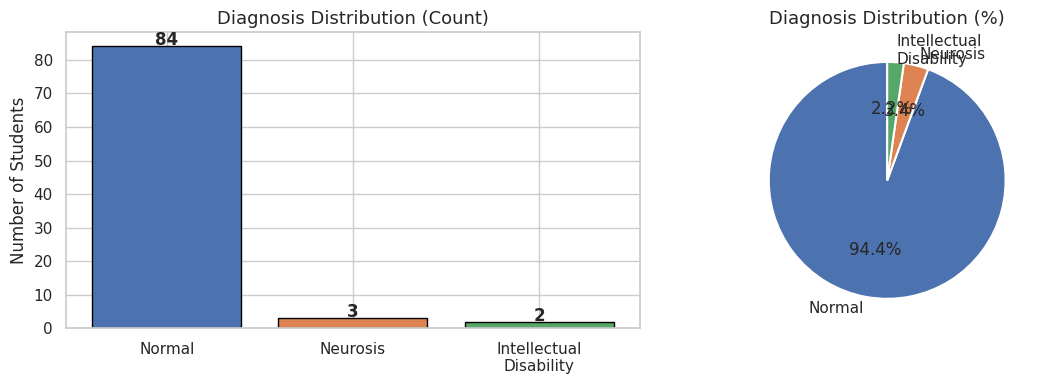

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df["diagnosis_label"].value_counts()
axes[0].bar(counts.index, counts.values, color=["#4C72B0","#DD8452","#55A868"], edgecolor="black")
axes[0].set_title("Diagnosis Distribution (Count)", fontsize=13)
axes[0].set_ylabel("Number of Students")
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=["#4C72B0","#DD8452","#55A868"], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title("Diagnosis Distribution (%)", fontsize=13)

plt.tight_layout()
plt.savefig("01_diagnosis_distribution.png", dpi=150)
plt.show()
print("WARNING: Class imbalance is severe: 94.4% Normal. SMOTE required in Member 3.")

## 2.4 Demographic Analysis
**Insight:** The sample is nearly balanced by gender (54% male, 46% female). Most students are aged 11–12, from 4th and 6th primary grades.

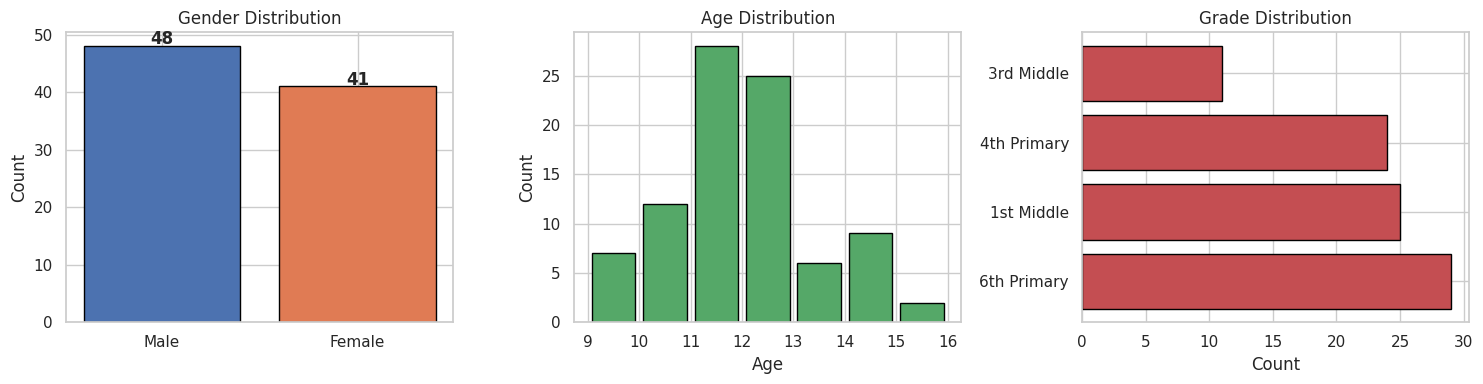

Age stats:
count    89.00
mean     11.52
std       1.42
min       9.00
25%      11.00
50%      11.00
75%      12.00
max      15.00
Name: age, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gender
g_counts = df["gender"].map({1:"Male",0:"Female"}).value_counts()
axes[0].bar(g_counts.index, g_counts.values, color=["#4C72B0","#E07B54"], edgecolor="black")
axes[0].set_title("Gender Distribution"); axes[0].set_ylabel("Count")
for bar, v in zip(axes[0].patches, g_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(v), ha='center', fontweight='bold')

# Age histogram
axes[1].hist(df["age"], bins=range(9,17), color="#55A868", edgecolor="black", rwidth=0.85)
axes[1].set_title("Age Distribution"); axes[1].set_xlabel("Age"); axes[1].set_ylabel("Count")
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

# Grade
grade_map = {"الرابع الإبتدائي":"4th Primary","السادس الإبتدائي":"6th Primary",
             "الأول إعدادى":"1st Middle","الثالث إعدادى":"3rd Middle"}
g_counts2 = df["grade"].map(grade_map).value_counts()
axes[2].barh(g_counts2.index, g_counts2.values, color="#C44E52", edgecolor="black")
axes[2].set_title("Grade Distribution"); axes[2].set_xlabel("Count")

plt.tight_layout()
plt.savefig("02_demographics.png", dpi=150)
plt.show()
print("Age stats:"); print(df["age"].describe().round(2))

## 2.5 Feature Frequency (How Common Is Each Feature?)
**Insight:** `curve_change` and `angle_change` are by far the most frequent errors (84% and 80% of students respectively), suggesting they are baseline perceptual difficulties in this age group rather than strong diagnostic indicators. `rotation` and `collision` are present in about 1/3 of students and may carry more diagnostic signal.

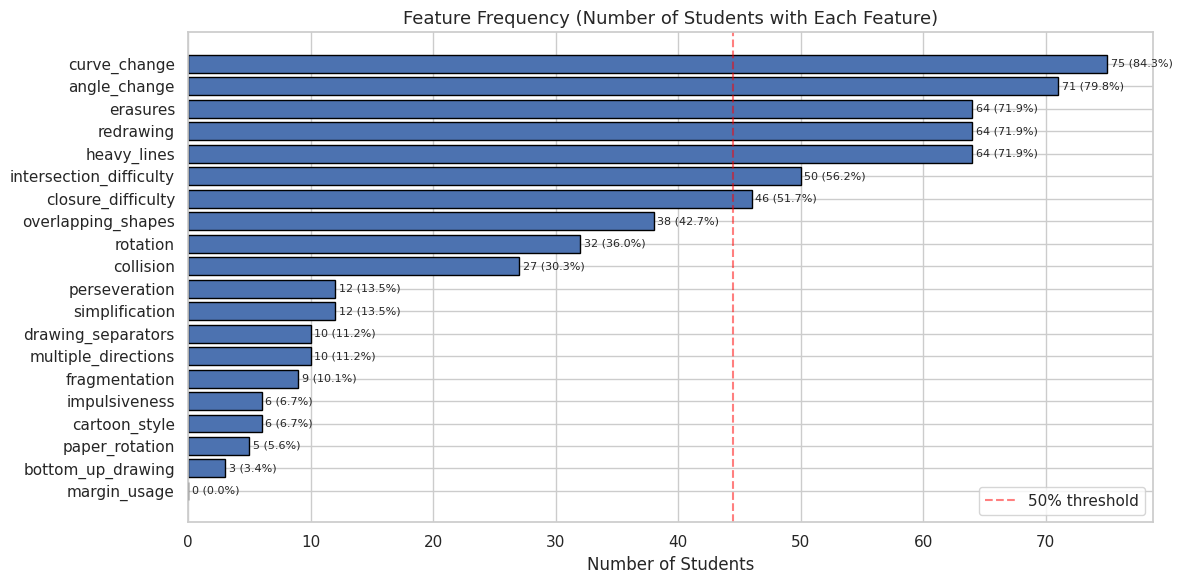

Feature frequencies:
                         count  pct%
curve_change                75  84.3
angle_change                71  79.8
erasures                    64  71.9
redrawing                   64  71.9
heavy_lines                 64  71.9
intersection_difficulty     50  56.2
closure_difficulty          46  51.7
overlapping_shapes          38  42.7
rotation                    32  36.0
collision                   27  30.3
perseveration               12  13.5
simplification              12  13.5
drawing_separators          10  11.2
multiple_directions         10  11.2
fragmentation                9  10.1
impulsiveness                6   6.7
cartoon_style                6   6.7
paper_rotation               5   5.6
bottom_up_drawing            3   3.4
margin_usage                 0   0.0


In [21]:
freq = df[feature_cols].sum().sort_values(ascending=False)
pct  = (freq / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(freq.index[::-1], freq.values[::-1], color="#4C72B0", edgecolor="black")
for bar, val, p in zip(bars, freq.values[::-1], pct.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val} ({p}%)", va='center', fontsize=8)
ax.set_title("Feature Frequency (Number of Students with Each Feature)", fontsize=13)
ax.set_xlabel("Number of Students")
ax.axvline(x=len(df)*0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig("03_feature_frequency.png", dpi=150)
plt.show()

print("Feature frequencies:")
print(pd.DataFrame({"count": freq, "pct%": pct}).to_string())

## 2.6 Feature Distribution by Diagnosis
**Insight:** Non-normal diagnoses show higher prevalence of nearly every feature. The Intellectual Disability group shows the highest rates of `rotation`, `simplification`, and `cartoon_style`. The Neurosis group shows very high rates of `rotation` and `closure_difficulty`.

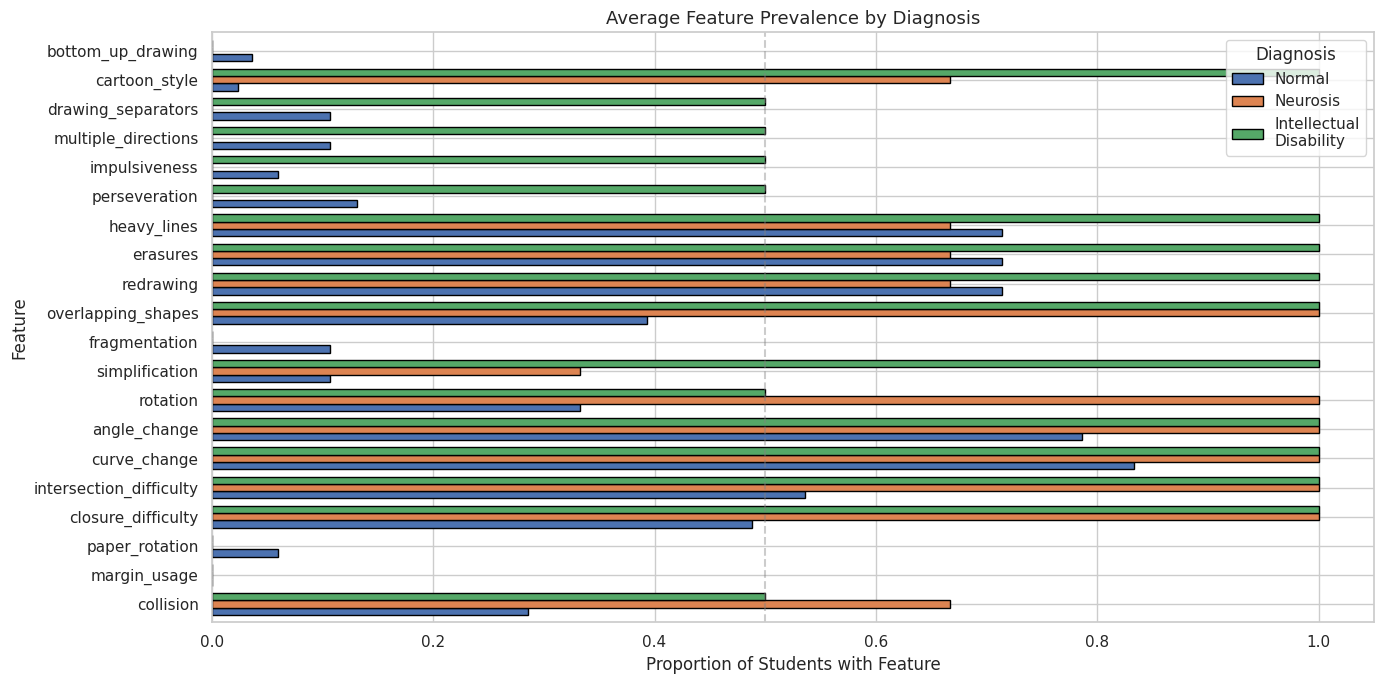

Mean feature rates by diagnosis:
diagnosis                Normal  Neurosis  Intellectual\nDisability
collision                 0.286     0.667                       0.5
margin_usage              0.000     0.000                       0.0
paper_rotation            0.060     0.000                       0.0
closure_difficulty        0.488     1.000                       1.0
intersection_difficulty   0.536     1.000                       1.0
curve_change              0.833     1.000                       1.0
angle_change              0.786     1.000                       1.0
rotation                  0.333     1.000                       0.5
simplification            0.107     0.333                       1.0
fragmentation             0.107     0.000                       0.0
overlapping_shapes        0.393     1.000                       1.0
redrawing                 0.714     0.667                       1.0
erasures                  0.714     0.667                       1.0
heavy_lines    

In [22]:
# Group mean by diagnosis
feature_by_diag = df.groupby("diagnosis")[feature_cols].mean().round(3)
feature_by_diag.index = feature_by_diag.index.map(DIAG_LABELS)

fig, ax = plt.subplots(figsize=(14, 7))
feature_by_diag.T.plot(kind="barh", ax=ax,
                        color=["#4C72B0","#DD8452","#55A868"],
                        edgecolor="black", width=0.75)
ax.set_title("Average Feature Prevalence by Diagnosis", fontsize=13)
ax.set_xlabel("Proportion of Students with Feature")
ax.set_ylabel("Feature")
ax.legend(title="Diagnosis")
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("04_features_by_diagnosis.png", dpi=150)
plt.show()

print("Mean feature rates by diagnosis:")
print(feature_by_diag.T.to_string())

## 2.7 Correlation Heatmap (Feature–Feature)
**Insight:** `redrawing` and `heavy_lines` are perfectly correlated (r=1.0) because they always appear together in the notes — confirming they capture the same clinical observation. Similarly `erasures` = `redrawing`. These three should be treated as one feature group to avoid multicollinearity. `curve_change` and `angle_change` also show high correlation (r≈0.45).

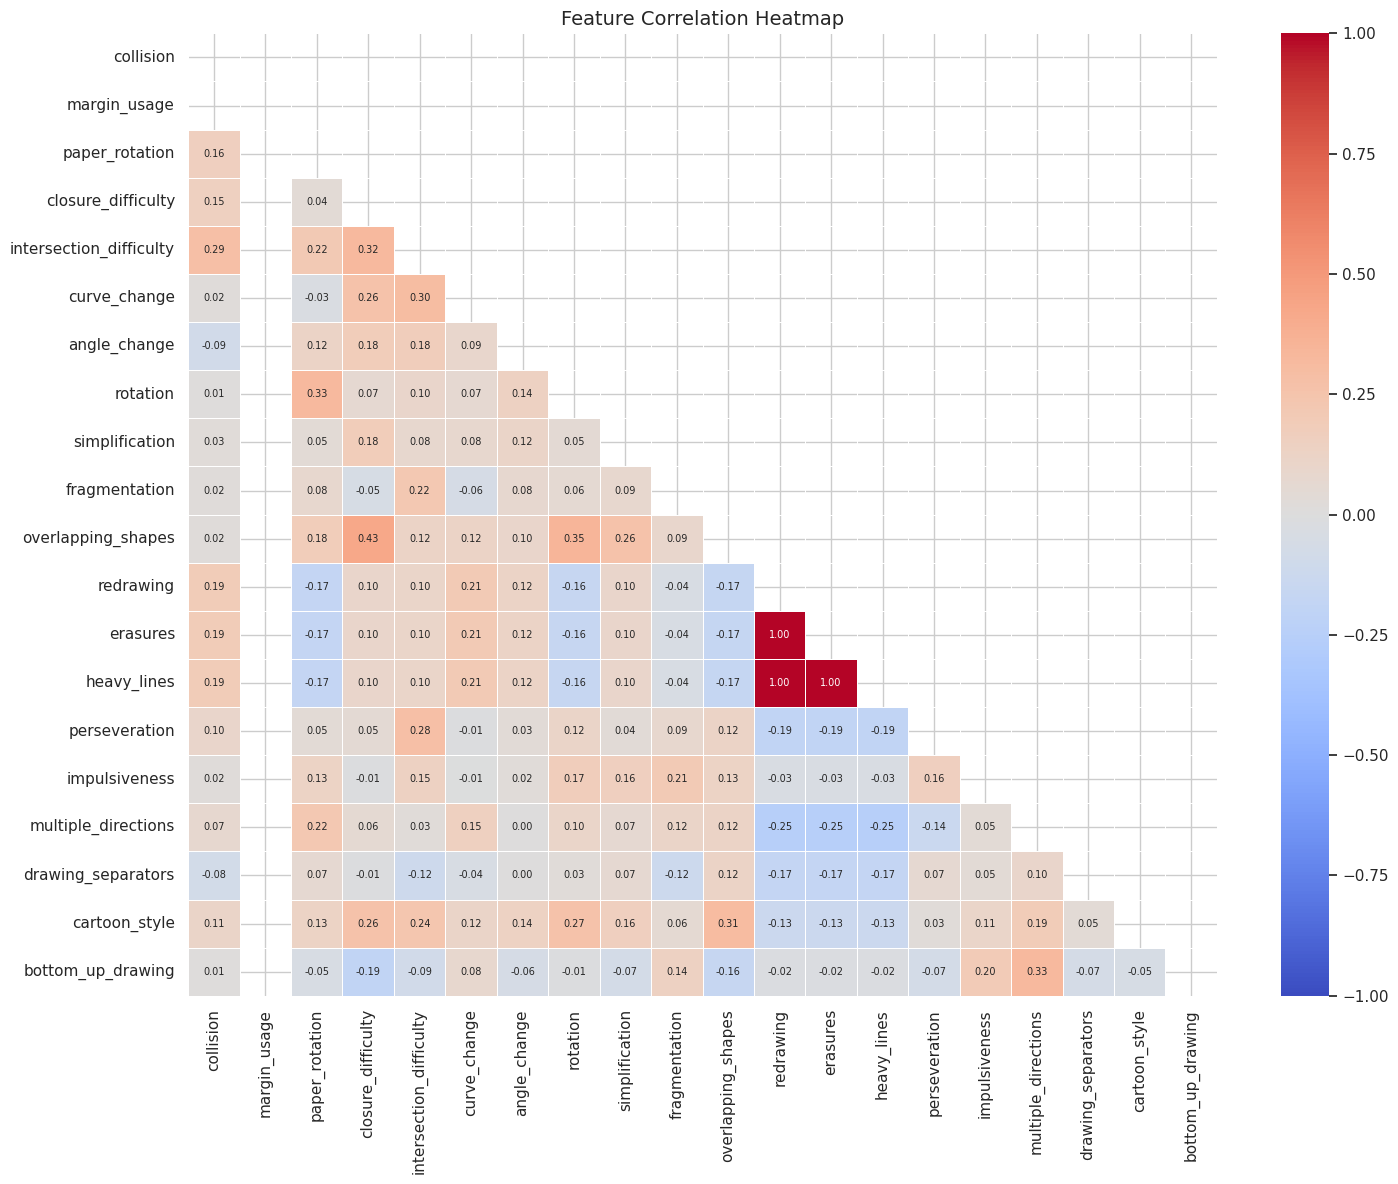

High correlations (|r| ≥ 0.7):
  redrawing ↔ erasures: r=1.0
  redrawing ↔ heavy_lines: r=1.0
  erasures ↔ heavy_lines: r=1.0


In [23]:
plt.figure(figsize=(15, 12))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            annot_kws={"size": 7}, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("05_correlation_heatmap.png", dpi=150)
plt.show()

# Flag high correlations
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i,j]
        if abs(r) >= 0.7:
            high_corr.append((corr.columns[i], corr.columns[j], round(r,3)))
print("High correlations (|r| ≥ 0.7):")
for a,b,r in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f"  {a} ↔ {b}: r={r}")

## 2.8 Diagnosis × Feature Heatmap
**Insight:** The heatmap clearly separates the three diagnostic groups. Intellectual Disability and Neurosis rows are much darker for `rotation`, `closure_difficulty`, `intersection_difficulty`, and `overlapping_shapes` compared to the Normal group.

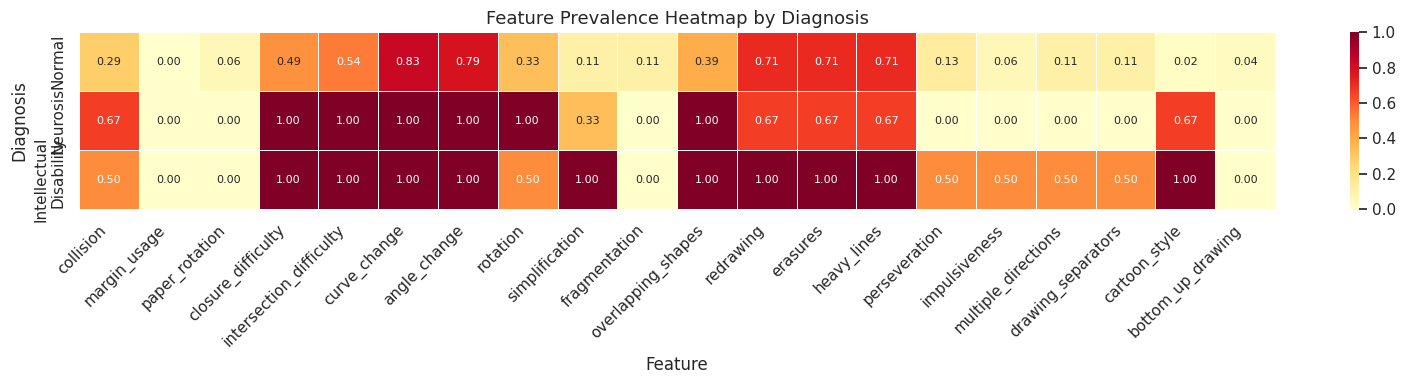

In [24]:
plt.figure(figsize=(16, 4))
sns.heatmap(feature_by_diag, annot=True, fmt=".2f",
            cmap="YlOrRd", linewidths=0.5,
            annot_kws={"size": 8}, vmin=0, vmax=1)
plt.title("Feature Prevalence Heatmap by Diagnosis", fontsize=13)
plt.xlabel("Feature")
plt.ylabel("Diagnosis")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("06_diagnosis_feature_heatmap.png", dpi=150)
plt.show()

## 2.9 Age Distribution by Diagnosis
**Insight:** Normal students span the full age range (9–15). The small number of non-normal cases (5 total) doesn't allow strong age-based conclusions, but non-normal cases tend to cluster slightly older. This may simply reflect the grade composition of the non-normal group.

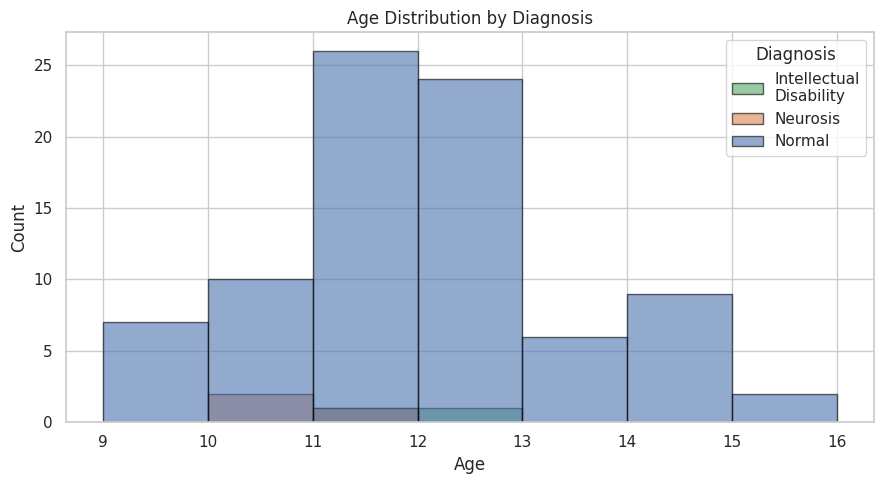

In [25]:
plt.figure(figsize=(9, 5))
colors = {"Normal": "#4C72B0", "Neurosis": "#DD8452", "Intellectual\nDisability": "#55A868"}
for diag_label, grp in df.groupby("diagnosis_label"):
    plt.hist(grp["age"], bins=range(9,17), alpha=0.6,
             label=diag_label, edgecolor="black",
             color=colors.get(diag_label, "gray"))
plt.title("Age Distribution by Diagnosis")
plt.xlabel("Age"); plt.ylabel("Count")
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.savefig("07_age_by_diagnosis.png", dpi=150)
plt.show()

## 2.10 Gender vs Diagnosis
**Insight:** Non-normal diagnoses appear in both genders, though the sample is too small (5 non-normal cases) to draw any gender-related conclusions.

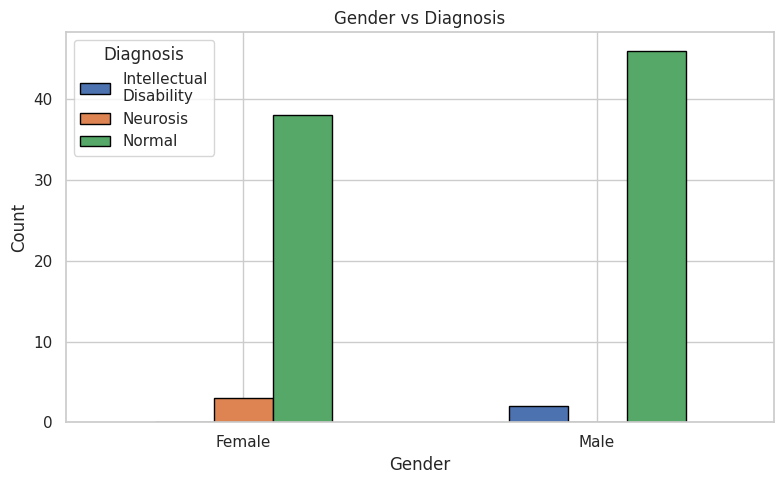

In [26]:
gender_diag = df.groupby(["gender","diagnosis_label"]).size().unstack(fill_value=0)
gender_diag.index = ["Female","Male"]
gender_diag.plot(kind="bar", figsize=(8,5),
                 color=["#4C72B0","#DD8452","#55A868"],
                 edgecolor="black")
plt.title("Gender vs Diagnosis")
plt.xlabel("Gender"); plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.savefig("08_gender_vs_diagnosis.png", dpi=150)
plt.show()

## 2.11 Sequence Type Analysis
**Insight:** Disorganized sequence (0) is the most common type (47% of students). Sequence type may have limited diagnostic discriminability since it's prevalent across all groups.

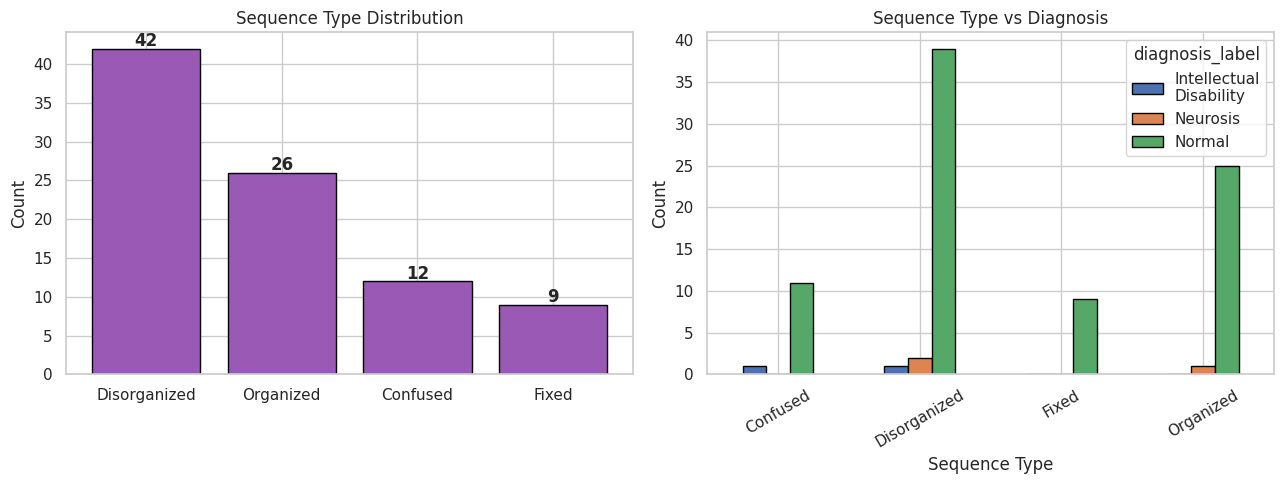

In [27]:
seq_map = {0:"Disorganized",1:"Organized",2:"Confused",3:"Fixed"}
df["sequence_label"] = df["sequence"].map(seq_map)

fig, axes = plt.subplots(1,2,figsize=(13,5))

# Overall distribution
seq_counts = df["sequence_label"].value_counts()
axes[0].bar(seq_counts.index, seq_counts.values, color="#9B59B6", edgecolor="black")
axes[0].set_title("Sequence Type Distribution")
axes[0].set_ylabel("Count")
for bar, v in zip(axes[0].patches, seq_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(v), ha='center', fontweight='bold')

# Sequence by diagnosis
seq_diag = df.groupby(["sequence_label","diagnosis_label"]).size().unstack(fill_value=0)
seq_diag.plot(kind="bar", ax=axes[1], color=["#4C72B0","#DD8452","#55A868"], edgecolor="black")
axes[1].set_title("Sequence Type vs Diagnosis")
axes[1].set_xlabel("Sequence Type"); axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("09_sequence_analysis.png", dpi=150)
plt.show()

## 2.12 Total Error Count Analysis
**Insight:** The total error count (sum of all binary features) shows a clear trend — non-normal students have significantly more errors. Neurosis averages ~8.7 errors and Intellectual Disability averages ~11.5 errors vs ~5.6 for Normal. This engineered feature could be a strong predictor.

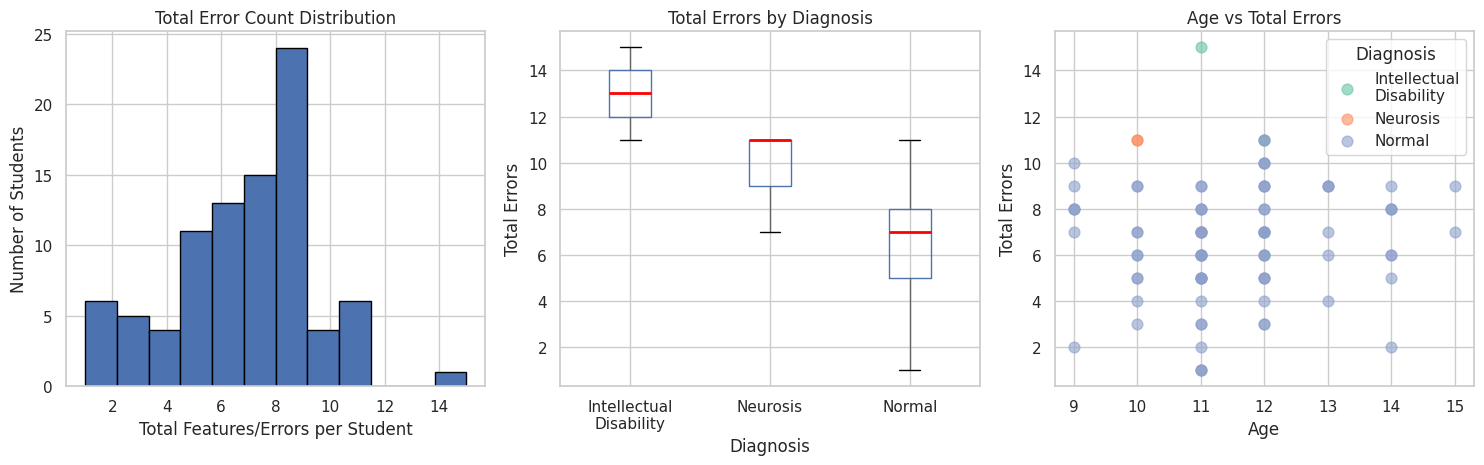

Total Errors by Diagnosis (mean ± std):
                           mean   std  min  max
diagnosis_label                                
Intellectual\nDisability  13.00  2.83   11   15
Neurosis                   9.67  2.31    7   11
Normal                     6.54  2.42    1   11


In [28]:
df["total_errors"] = df[feature_cols].sum(axis=1)

fig, axes = plt.subplots(1,3, figsize=(15,5))

# Distribution
axes[0].hist(df["total_errors"], bins=12, color="#4C72B0", edgecolor="black")
axes[0].set_title("Total Error Count Distribution")
axes[0].set_xlabel("Total Features/Errors per Student")
axes[0].set_ylabel("Number of Students")

# Box plot by diagnosis
df.boxplot(column="total_errors", by="diagnosis_label", ax=axes[1],
           boxprops=dict(color="#4C72B0"),
           medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Total Errors by Diagnosis")
plt.sca(axes[1]); plt.title("Total Errors by Diagnosis"); plt.suptitle("")
axes[1].set_xlabel("Diagnosis"); axes[1].set_ylabel("Total Errors")

# Scatter: age vs total_errors coloured by diagnosis
for diag_label, grp in df.groupby("diagnosis_label"):
    axes[2].scatter(grp["age"], grp["total_errors"], alpha=0.6, label=diag_label, s=60)
axes[2].set_title("Age vs Total Errors")
axes[2].set_xlabel("Age"); axes[2].set_ylabel("Total Errors")
axes[2].legend(title="Diagnosis")

plt.tight_layout()
plt.savefig("10_total_errors.png", dpi=150)
plt.show()

print("Total Errors by Diagnosis (mean ± std):")
print(df.groupby("diagnosis_label")["total_errors"].agg(["mean","std","min","max"]).round(2))

## 2.13 EDA Summary & Key Insights for Member 3




#  Member 3 — Preprocessing & Balancing Specialist
**Goal:** Prepare the final ML-ready dataset — handle class imbalance, encode remaining categoricals, scale features, and produce train/test splits.

## 3.1 Imports

In [62]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

## 3.2 Load & Inspect
Start from the cleaned dataset produced by Member 1.

In [65]:
df = cleaned_df.copy()

print("Shape:", df.shape)
print("\nDiagnosis distribution (raw):")
print(df["diagnosis"].value_counts().rename(DIAG_LABELS))
print("\nData types:")
print(df.dtypes)

Shape: (89, 28)

Diagnosis distribution (raw):
diagnosis
Normal                      84
Neurosis                     3
Intellectual\nDisability     2
Name: count, dtype: int64

Data types:
name                         object
gender                        int64
grade                        object
age                           int64
sequence                      int64
drawing_position              int64
distance_between_drawings     int64
collision                     int64
margin_usage                  int64
paper_rotation                int64
closure_difficulty            int64
intersection_difficulty       int64
curve_change                  int64
angle_change                  int64
rotation                      int64
simplification                int64
fragmentation                 int64
overlapping_shapes            int64
redrawing                     int64
erasures                      int64
heavy_lines                   int64
perseveration                 int64
impulsiveness      

## 3.3 Drop Unusable Columns
Columns with zero variance carry no information and must be removed before modeling.

In [66]:
zero_var_cols = ["drawing_position", "margin_usage"]
print("Dropping zero-variance columns:", zero_var_cols)

drop_cols = zero_var_cols + ["name"]
df_ml = df.drop(columns=[c for c in drop_cols if c in df.columns])

for col in ["diagnosis_label", "sequence_label", "total_errors"]:
    if col in df_ml.columns:
        df_ml = df_ml.drop(columns=[col])

print("Shape after dropping:", df_ml.shape)
print("Remaining columns:", df_ml.columns.tolist())

Dropping zero-variance columns: ['drawing_position', 'margin_usage']
Shape after dropping: (89, 25)
Remaining columns: ['gender', 'grade', 'age', 'sequence', 'distance_between_drawings', 'collision', 'paper_rotation', 'closure_difficulty', 'intersection_difficulty', 'curve_change', 'angle_change', 'rotation', 'simplification', 'fragmentation', 'overlapping_shapes', 'redrawing', 'erasures', 'heavy_lines', 'perseveration', 'impulsiveness', 'multiple_directions', 'drawing_separators', 'cartoon_style', 'bottom_up_drawing', 'diagnosis']


## 3.4 Encode Remaining Categorical Columns
The `grade` column is still a string and must be encoded.

In [67]:
grade_order = {
    "الرابع الإبتدائي": 0,
    "السادس الإبتدائي": 1,
    "الأول إعدادى":    2,
    "الثالث إعدادى":  3,
}
df_ml["grade"] = df_ml["grade"].map(grade_order)

print("Grade distribution after encoding:")
print(df_ml["grade"].value_counts().sort_index())
print("\nAny remaining non-numeric columns:")
print(df_ml.select_dtypes(include='object').columns.tolist())

Grade distribution after encoding:
grade
0    24
1    29
2    25
3    11
Name: count, dtype: int64

Any remaining non-numeric columns:
[]


## 3.5 Address Highly Correlated Features


In [68]:
corr_drops = ["erasures", "heavy_lines"]
df_ml_reduced = df_ml.drop(columns=corr_drops)
print("Dropped for multicollinearity:", corr_drops)
print("Shape after multicollinearity reduction:", df_ml_reduced.shape)

X_check = df_ml_reduced.drop(columns=["diagnosis"])
corr_max = X_check.corr().abs().where(np.triu(np.ones(X_check.corr().shape), k=1).astype(bool)).max().max()
print(f"Max remaining pairwise correlation: {corr_max:.3f}")

Dropped for multicollinearity: ['erasures', 'heavy_lines']
Shape after multicollinearity reduction: (89, 23)
Max remaining pairwise correlation: 0.916


## 3.6 Separate Features & Target

In [69]:
X = df_ml_reduced.drop(columns=["diagnosis"])
y = df_ml_reduced["diagnosis"]

print("Features (X):", X.shape)
print("Target  (y):", y.shape)
print("\nFeature list:", X.columns.tolist())
print("\nClass distribution:")
for cls, cnt in sorted(Counter(y).items()):
    label = DIAG_LABELS.get(cls, str(cls))
    print(f"  Class {cls} ({label}): {cnt} samples")

Features (X): (89, 22)
Target  (y): (89,)

Feature list: ['gender', 'grade', 'age', 'sequence', 'distance_between_drawings', 'collision', 'paper_rotation', 'closure_difficulty', 'intersection_difficulty', 'curve_change', 'angle_change', 'rotation', 'simplification', 'fragmentation', 'overlapping_shapes', 'redrawing', 'perseveration', 'impulsiveness', 'multiple_directions', 'drawing_separators', 'cartoon_style', 'bottom_up_drawing']

Class distribution:
  Class 0 (Normal): 84 samples
  Class 1 (Neurosis): 3 samples
  Class 2 (Intellectual
Disability): 2 samples


## 3.7 Train / Test Split (Stratified)
With only 89 samples and severe class imbalance, stratified splitting is **mandatory** to ensure all classes appear in both sets.

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print("\nTrain class distribution:")
for cls, cnt in sorted(Counter(y_train).items()):
    print(f"  Class {cls} ({DIAG_LABELS.get(cls,cls)}): {cnt}")
print("\nTest class distribution:")
for cls, cnt in sorted(Counter(y_test).items()):
    print(f"  Class {cls} ({DIAG_LABELS.get(cls,cls)}): {cnt}")

Train: 71 samples  |  Test: 18 samples

Train class distribution:
  Class 0 (Normal): 67
  Class 1 (Neurosis): 2
  Class 2 (Intellectual
Disability): 2

Test class distribution:
  Class 0 (Normal): 17
  Class 1 (Neurosis): 1


## 3.8 Handle Class Imbalance with SMOTE


In [71]:
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE — Train class distribution:")
for cls, cnt in sorted(Counter(y_train).items()):
    print(f"  Class {cls} ({DIAG_LABELS.get(cls,cls)}): {cnt}")

print("\nAfter SMOTE — Train class distribution:")
for cls, cnt in sorted(Counter(y_train_bal).items()):
    print(f"  Class {cls} ({DIAG_LABELS.get(cls,cls)}): {cnt}")

print(f"\nX_train shape before SMOTE: {X_train.shape}")
print(f"X_train shape after  SMOTE: {X_train_bal.shape}")

Before SMOTE — Train class distribution:
  Class 0 (Normal): 67
  Class 1 (Neurosis): 2
  Class 2 (Intellectual
Disability): 2

After SMOTE — Train class distribution:
  Class 0 (Normal): 67
  Class 1 (Neurosis): 67
  Class 2 (Intellectual
Disability): 67

X_train shape before SMOTE: (71, 22)
X_train shape after  SMOTE: (201, 22)


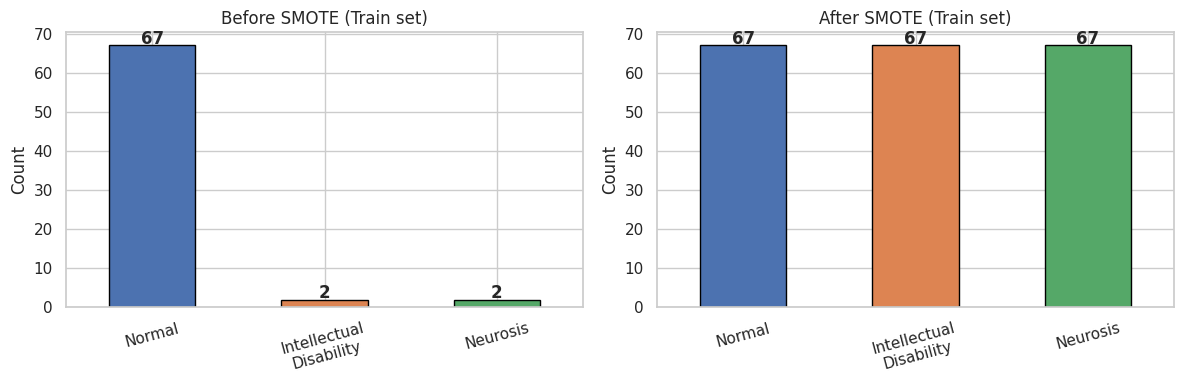

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = pd.Series(Counter(y_train)).rename(DIAG_LABELS)
after  = pd.Series(Counter(y_train_bal)).rename(DIAG_LABELS)

before.plot(kind="bar", ax=axes[0], color=["#4C72B0","#DD8452","#55A868"], edgecolor="black")
axes[0].set_title("Before SMOTE (Train set)")
axes[0].set_ylabel("Count"); axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(axes[0].patches, before.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(v), ha='center', fontweight='bold')

after.plot(kind="bar", ax=axes[1], color=["#4C72B0","#DD8452","#55A868"], edgecolor="black")
axes[1].set_title("After SMOTE (Train set)")
axes[1].set_ylabel("Count"); axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(axes[1].patches, after.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("11_smote_balance.png", dpi=150)
plt.show()

## 3.9 Feature Scaling


In [73]:
scaler = MinMaxScaler()

# Fit ONLY on the balanced training set
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("Scaling complete (MinMaxScaler fitted on training set only)")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print("\nFeature ranges after scaling (should all be 0–1):")
print(X_train_scaled.describe().loc[["min","max"]].round(3))

Scaling complete (MinMaxScaler fitted on training set only)
X_train_scaled: (201, 22)
X_test_scaled:  (18, 22)

Feature ranges after scaling (should all be 0–1):
     gender  grade  age  sequence  distance_between_drawings  collision  \
min     0.0    0.0  0.0       0.0                        0.0        0.0   
max     1.0    1.0  1.0       1.0                        1.0        1.0   

     paper_rotation  closure_difficulty  intersection_difficulty  \
min             0.0                 0.0                      0.0   
max             1.0                 1.0                      1.0   

     curve_change  ...  simplification  fragmentation  overlapping_shapes  \
min           0.0  ...             0.0            0.0                 0.0   
max           1.0  ...             1.0            1.0                 1.0   

     redrawing  perseveration  impulsiveness  multiple_directions  \
min        0.0            0.0            0.0                  0.0   
max        1.0            1.0        

## 3.10 Stratified K-Fold Setup for Member 4


In [74]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Stratified 5-Fold CV — fold sizes on the SMOTE-balanced training set:")
print(f"  Total training samples (after SMOTE): {len(X_train_bal)}")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_bal, y_train_bal), 1):
    tr_dist  = Counter(y_train_bal.iloc[tr_idx])
    val_dist = Counter(y_train_bal.iloc[val_idx])
    print(f"  Fold {fold}: train={len(tr_idx)}, val={len(val_idx)}  | val classes: {dict(val_dist)}")

print("\nskf object ready to pass to Member 4.")
print("Usage: cross_val_score(model, X_train_bal, y_train_bal, cv=skf, scoring='f1_macro')")

Stratified 5-Fold CV — fold sizes on the SMOTE-balanced training set:
  Total training samples (after SMOTE): 201
  Fold 1: train=160, val=41  | val classes: {2: 13, 0: 14, 1: 14}
  Fold 2: train=161, val=40  | val classes: {0: 14, 1: 13, 2: 13}
  Fold 3: train=161, val=40  | val classes: {0: 13, 1: 13, 2: 14}
  Fold 4: train=161, val=40  | val classes: {0: 13, 2: 14, 1: 13}
  Fold 5: train=161, val=40  | val classes: {0: 13, 1: 14, 2: 13}

skf object ready to pass to Member 4.
Usage: cross_val_score(model, X_train_bal, y_train_bal, cv=skf, scoring='f1_macro')


## Save Processed Datasets

In [76]:

X_train_scaled.to_csv("X_train.csv", index=False)
X_test_scaled.to_csv("X_test.csv", index=False)
y_train_bal.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv")

Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv
